## Practice Lecture 16: Unsupervised Learning
In this lab we will use Dimensionality Reduction methods for classification. \
Based on Chapter 9 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice16Unsupervised.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "unsupervised_learning"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

### Exercise 1: clustering
For the dataset below, use sklearn k-means and plot how it evolves with iterations 1 and 5.\
Use the example on the notebook to write your 2x2 plot.\
Visualize the movement of the centroids on the left column and the boundaries on the right column

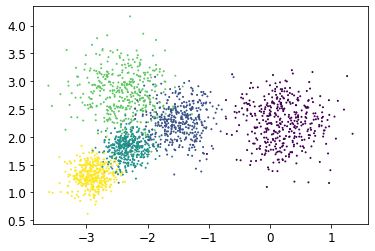

In [3]:
from sklearn.datasets import make_blobs
blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.3,  1.8],
     [-2.4,  2.8],
     [-2.9,  1.3]])
blob_std = np.array([0.4, 0.3, 0.2, 0.4, 0.2])
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=1)

To do unsupervised clustering we need to work without labels (without y)

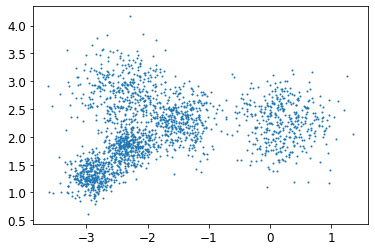

In [4]:
#let us remove the labels to do unsupervised clustering
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=None, s=1)

In [5]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
print('X shape', X.shape)
print('y_pred shape', y_pred.shape)
print('labels',kmeans.labels_)
print('y_pred', y_pred)
print('centers', kmeans.cluster_centers_)

X shape (2000, 2)
y_pred shape (2000,)
labels [3 1 0 ... 2 0 1]
y_pred [3 1 0 ... 2 0 1]
centers [[ 0.21291772  2.25399958]
 [-2.29691244  1.85702648]
 [-2.43742863  2.89912413]
 [-2.89435335  1.30831759]
 [-1.4434708   2.30795331]]


In [11]:
(kmeans.labels_ == y_pred)

array([ True,  True,  True, ...,  True,  True,  True])

In [12]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 0, 2, 2], dtype=int32)

In [13]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=50, linewidths=50,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

To illustrate the changes with iterations, we will use two clusters with 1 and 5 iterations.\
(the jump from 1 to 5 is just to make changes more obvious, you can use 1 and 2 to see how much change in 1 iter).

In [20]:
kmeans_iter1 = KMeans(n_clusters=5,init="random", n_init=1,
                     algorithm="full", max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=5,init="random", n_init=1,
                     algorithm="full", max_iter=5, random_state=1)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)

KMeans(algorithm='full', copy_x=True, init='random', max_iter=5, n_clusters=5,
       n_init=1, n_jobs=None, precompute_distances='auto', random_state=1,
       tol=0.0001, verbose=0)

The following plots plots illustrate how the kmeans algorithm work. 
- initial cluster centers (random initialization)
- calculate the distance between each sample and the centroids, assign the labels (and boundaries).
- with the assigned labels calculate new centroids. 
- with the new centroids calculate the new labels.

Text(0.5, 1.0, 'same centroids, new labels')

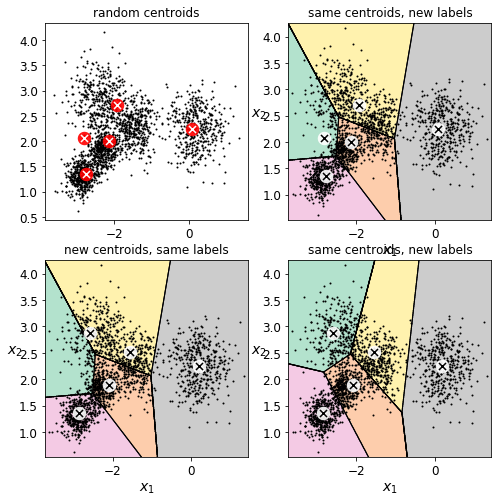

In [21]:
plt.figure(figsize=(8, 8))
plt.subplot(221)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.title('random centroids')
plt.subplot(222)
plot_decision_boundaries(kmeans_iter1, X)
plt.title('same centroids, new labels')
plt.subplot(223)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False)
plot_centroids(kmeans_iter2.cluster_centers_)
plt.title('new centroids, same labels')
plt.subplot(224)
plot_decision_boundaries(kmeans_iter2, X)
plt.title('same centroids, new labels')

### Exercise 2: Cluster best models
Create clusters with different parameters and estimate their quality by using inertia.\
First try using different number of clusters.\
Then do the same with the different initialization parameters.

In [41]:
kmeans_v1 = KMeans(n_clusters=4, init="random", n_init=1,
                         algorithm="full", random_state=42)
kmeans_v2 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="full", random_state=42)
kmeans_v3 = KMeans(n_clusters=6, init="random", n_init=1,
                         algorithm="full", random_state=42)
kmeans_v1.fit(X)
kmeans_v2.fit(X)
kmeans_v3.fit(X)

KMeans(algorithm='full', copy_x=True, init='random', max_iter=300, n_clusters=6,
       n_init=1, n_jobs=None, precompute_distances='auto', random_state=42,
       tol=0.0001, verbose=0)

In [43]:
print(kmeans_v1.inertia_)
print(kmeans_v2.inertia_)
print(kmeans_v3.inertia_)

452.3828135344867
333.3354079442936
291.1302957760049


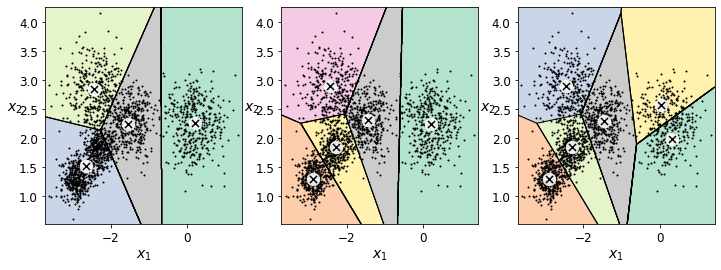

In [47]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plot_decision_boundaries(kmeans_v1, X)
plt.subplot(132)
plot_decision_boundaries(kmeans_v2, X)
plt.subplot(133)
plot_decision_boundaries(kmeans_v3, X)


Another way to test, we can create several clusters and plot their inertia

In [91]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

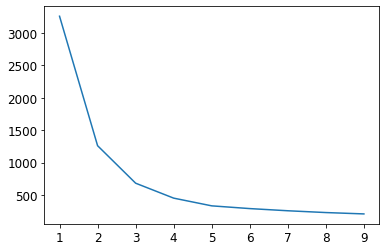

In [97]:
k=np.arange(1,10)
plt.plot(k,inertias)

The inertia decays as we have more clusters, so it needs to be taken into account.
The following metric is more accurate

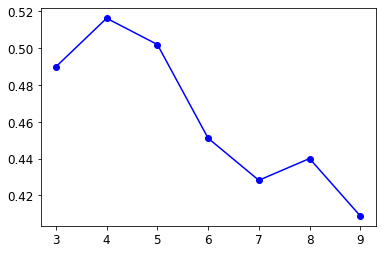

In [102]:
from sklearn.metrics import silhouette_score
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[2:]]
plt.plot(range(3, 10), silhouette_scores, "bo-")

Let us try now different initializations

In [88]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans_v1 = KMeans(n_clusters=5)
#kmeans_v1 = KMeans(n_clusters=5, random_state=10)
kmeans_v2 = KMeans(n_clusters=5, init=good_init, n_init=1,algorithm="full")
kmeans_v3 = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=42)


kmeans_v1.fit(X)
kmeans_v2.fit(X)
kmeans_v3.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=5, n_init=1, n_jobs=None, precompute_distances='auto',
       random_state=42, tol=0.0001, verbose=0)

In [89]:
print(kmeans_v1.inertia_)
print(kmeans_v2.inertia_)
print(kmeans_v3.inertia_)

333.3301714149891
333.33484239300424
333.3334690006021


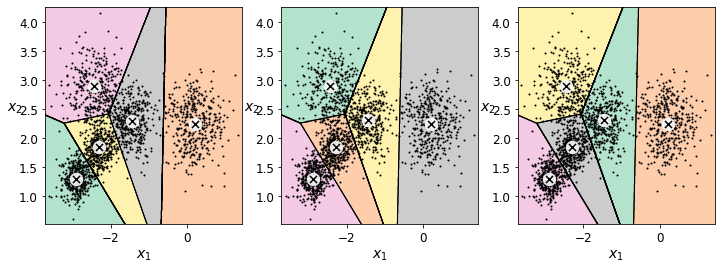

In [90]:
plt.figure(figsize=(12,4))
plt.subplot(131)
plot_decision_boundaries(kmeans_v1, X)
plt.subplot(132)
plot_decision_boundaries(kmeans_v2, X)
plt.subplot(133)
plot_decision_boundaries(kmeans_v3, X)

### Exercise 3: Irregular clusters 
For the data below, try to fit a cluster without initial centers then giving the centers given below.

In [107]:
good_init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]])
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

In [109]:
kmeans_good = KMeans(n_clusters=3, init=good_init, n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=42, tol=0.0001, verbose=0)

Text(0.5, 1.0, 'Inertia = 2179.5')

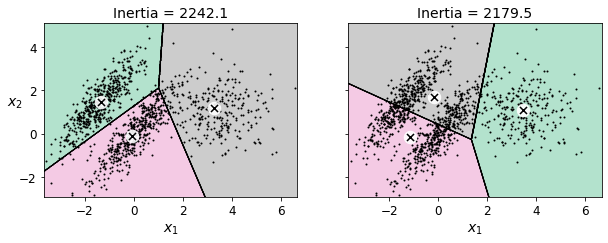

In [111]:
plt.figure(figsize=(10, 3.2))
plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title("Inertia = {:.1f}".format(kmeans_good.inertia_), fontsize=14)
plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title("Inertia = {:.1f}".format(kmeans_bad.inertia_), fontsize=14)


### Exercise 4:
Using a Gaussian mixture model to separate the Iris dataset. Visually compare the predicted labels to the original labels.

In [9]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target

In [15]:
from sklearn.mixture import GaussianMixture
gm=GaussianMixture(n_components=3)
gm.fit(X)

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=3, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [22]:
y_pred=gm.predict(X)
print(y_pred.shape)
print(X.shape)
print(data.target_names)
print(data.feature_names)

(150,)
(150, 4)
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Text(0.5, 0, 'Petal length')

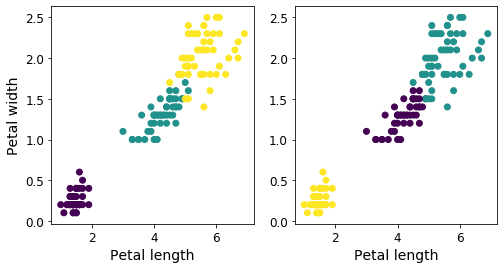

In [38]:
plt.figure(figsize=(8,4))
plt.subplot(121);plt.scatter(X[:,2],X[:,3],c=y)
plt.xlabel("Petal length");plt.ylabel("Petal width")
plt.subplot(122);plt.scatter(X[:,2],X[:,3],c=y_pred)
plt.xlabel("Petal length")


### Exercise 3:
Use a Gaussian mixture model to classify the moons data set.\
Check the model has converged and in how many iterations.\
Then make the problem harder so it needs more iterations.\
Plot the decision boundaries for both cases (use plotting functions from notebook)

(1000, 2)
(250, 2)


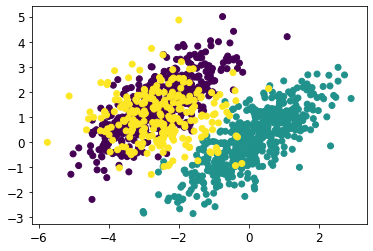

In [110]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.274, 0.95], [0.932, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
#X2 = X2 + [6, -8]
X2 = X2 + [0, -8]
y2=y2+2
print(X1.shape)
print(X2.shape)
X = np.r_[X1, X2]
y = np.r_[y1, y2]
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y)

In [111]:
from sklearn.mixture import GaussianMixture
gm=GaussianMixture(n_components=3)
gm.fit(X)

GaussianMixture(covariance_type='full', init_params='kmeans', max_iter=100,
                means_init=None, n_components=3, n_init=1, precisions_init=None,
                random_state=None, reg_covar=1e-06, tol=0.001, verbose=0,
                verbose_interval=10, warm_start=False, weights_init=None)

In [112]:
print('weights=',gm.weights_)
print('means=\n',gm.means_)
print('covariances=\n',gm.covariances_)

weights= [0.23910758 0.58185432 0.1790381 ]
means=
 [[-0.44656876 -0.50217637]
 [-2.61413014  1.33875312]
 [ 0.69149888  0.91325683]]
covariances=
 [[[0.76369158 0.49345869]
  [0.49345869 0.78491397]]

 [[0.88238728 0.57583331]
  [0.57583331 1.09112303]]

 [[0.68695286 0.39082083]
  [0.39082083 0.6428165 ]]]


True
3


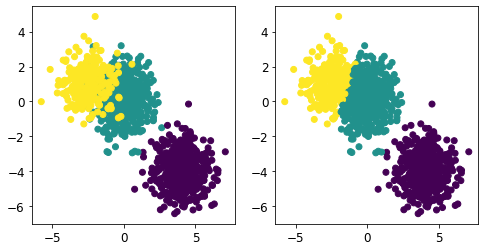

In [98]:
y_pred=gm.predict(X)
plt.figure(figsize=(8,4))
plt.subplot(121);plt.scatter(X[:,0],X[:,1],c=y)
plt.subplot(122);plt.scatter(X[:,0],X[:,1],c=y_pred)
print(gm.converged_)
print(gm.n_iter_)

In [99]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')
    
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$", fontsize=14)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

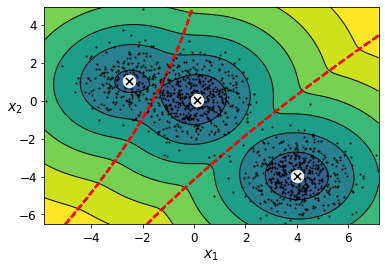

In [100]:
plot_gaussian_mixture(gm,X)

## Exercise 4:
Use Bayesian Gaussian Mixture to estimate the optimal number of clusters in the data set below.\
Use the plot_gaussian_mixture function from the notebook to plot the boundaries.\
Experiment with different number of clusters.


(1000, 2)


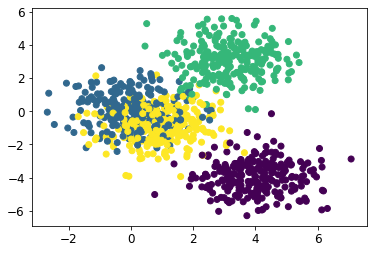

In [114]:
X, y = make_blobs(n_samples=1000, centers=((4, -4), (0, 0), (3,3), (1,-1)), random_state=42)
print(X.shape)
plt.figure()
plt.scatter(X[:,0],X[:,1],c=y)

In [127]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, max_iter=1000)
bgm.fit(X)
print(bgm.n_iter_)
print(np.round(bgm.weights_,2))

509
[0.   0.   0.25 0.   0.   0.5  0.   0.25 0.   0.  ]


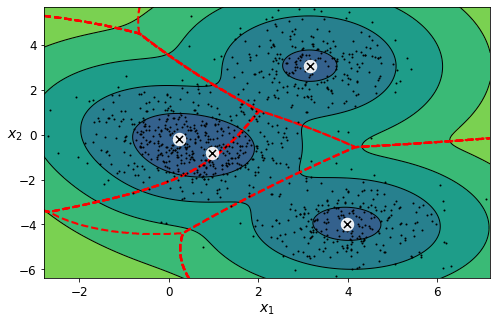

In [119]:
plt.figure(figsize=(8, 5))
plot_gaussian_mixture(bgm, X)
plt.show()